# Lab 3 — Semantic Search

Run this notebook top to bottom as you build out `embeddings.py` and `search.py` in this same folder. See `Lab3_Instructions.md` for what belongs in each step.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the corpus, example queries, and visualization are yours to write.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from search import load_documents, build_embedding_matrix, search

## Step 1-2: Load your corpus and fetch embeddings

In [ ]:
# TODO: load_documents("documents.json") and build_embedding_matrix(documents)
# Start in offline mode (the default) while you're building - switch to the real
# API once your pipeline works end to end.

documents = load_documents("documents.json")
embedding_matrix = build_embedding_matrix(documents)

Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for input_type='passage'...
Fetching embedding using NVIDIA NIM API for inpu

## Step 3: Run a few example search queries

In [ ]:
# TODO: call search(query, embedding_matrix, documents, top_k=3) with at least two
# different queries and print the results
search_results_1 = search("what is computer science?", embedding_matrix, documents, top_k=3)
print("Search results for query 1: 'what is computer science?'")
for result in search_results_1:
    print(result)

print()
search_results_2 = search("how far does light travel in a year?", embedding_matrix, documents, top_k=3)
print("Search results for query 2: 'how far does light travel in a year?'")
for result in search_results_2:
    print(result)


Fetching embedding using NVIDIA NIM API for input_type='query'...
Search results for query 1: 'what is computer science?'
({'topic': 'astronomy', 'text': 'A black hole is a region where gravity is so strong that nothing, not even light, can escape.', 'id': 2}, np.float64(0.22007735884351742))
({'topic': 'astronomy', 'text': 'The Sun is a medium-sized star at the center of our solar system, about 150 million kilometers from Earth.', 'id': 3}, np.float64(0.21946064295350562))
({'topic': 'music', 'text': 'A symphony is a long-form musical composition for orchestra, usually in four movements.', 'id': 18}, np.float64(0.20599053557330188))

Fetching embedding using NVIDIA NIM API for input_type='query'...
Search results for query 2: 'how far does light travel in a year?'
({'topic': 'astronomy', 'text': 'A light-year measures distance, not time - it is the distance light travels in one year.', 'id': 0}, np.float64(0.43584505491537884))
({'topic': 'astronomy', 'text': 'The Sun is a medium-size

## Step 4: Visualize the embedding space with PCA

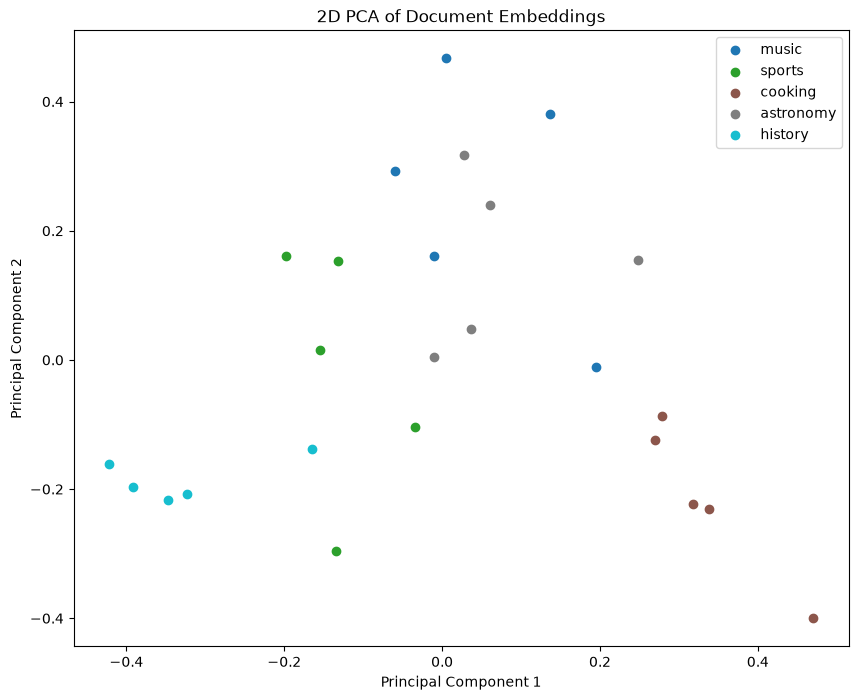

In [ ]:
# TODO: reuse your Lab 2 PCA-via-SVD function (extended to 2 components) to project
# the embedding matrix down to 2D, then scatter-plot it colored by topic
# I also want to plot the query embeddings on the same plot, so you can see how they relate to the document clusters.
from search import pca_2d
embedding_matrix_2d = pca_2d(embedding_matrix)

#scatter plot
plt.figure(figsize=(10, 8))
# Get unique topics and assign colors
unique_topics = list(set(doc['topic'] for doc in documents))
colors = plt.get_cmap('tab10', len(unique_topics))
for i, topic in enumerate(unique_topics):
    topic_embeddings = embedding_matrix_2d[[doc['topic'] == topic for doc in documents]]
    plt.scatter(topic_embeddings[:, 0], topic_embeddings[:, 1], label=topic, color=colors(i))
plt.title("2D PCA of Document Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()



## Step 4 (continued): What the plot shows

Each dot represents one document. Similar documents appear close together, while different ones are farther apart.
PCA reduces high-dimensional embeddings to two dimensions (PC1 and PC2) so they can be visualized.

In offline mode, clusters are not perfectly separated because documents are grouped by shared words rather than meaning.
History forms the clearest cluster, while music, sports, and astronomy overlap more.
 Since the first two principal components capture only about 23% of the variation, the plot is a simplified view. 
 Semantic (API) embeddings would produce much cleaner clusters.
